# Stage 1 — Build H from the digitized Khilkevitch Fig. 1 and validate end-to-end

### Logic flow
1. Point `DATA_DIR` at CSV folder; a keyword resolver finds each file.
2. Common energy grid  ->  resample `x_true` (the known input).
3. Build `H` (calibrated-Gaussian first pass; flagged limits).
4. Forward check `y = H @ x_true` vs Fig 1b  ->  validates `H`.
5. MLEM (explicit Richardson-Lucy loop).
6. Run 1 self-consistency; Run 2 real benchmark.

> **Scope.** Khilkevitch is detector-only: `x` is a photon spectrum, `H` is the DRF alone. The
> bremsstrahlung layer `H_e` (electron -> photon) is a separate later layer for the RE problem.


## Imports and a single CSV loader

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_digitized(path):
    """Load one Plot-Digitizer CSV into a clean (x, y) table.

    Digitizer output has no header, may contain several hits on the same x-pixel, and is not
    guaranteed sorted. We average duplicate-x hits and sort by energy so that downstream
    interpolation sees a single-valued, increasing curve.
    """
    df = pd.read_csv(path, header=None, names=["x", "y"])
    df = df.groupby("x", as_index=False).mean()
    df = df.sort_values("x").reset_index(drop=True)
    return df

## Step 0 — locate the data

The resolver below matches each curve by **keywords**, so it does not care whether the filenames use `graph_a(3MeV).csv` or
`graph_a_3MeV_.csv`. 

If a file can't be matched, it prints everything actually in the folder so you
can see the real names immediately.

In [2]:
DATA_DIR = Path(r"C:\Users\user\OneDrive\Desktop\Summer Project 2026\data")

PATTERNS = {
    "drf_3MeV":    ["graph_a", "3mev"],                  # Fig 1a: response to 3 MeV photons
    "drf_6MeV":    ["graph_a", "6mev"],                  # Fig 1a: response to 6 MeV photons
    "drf_8MeV":    ["graph_a", "8mev"],                  # Fig 1a: response to 8 MeV photons
    "fig1b_meas":  ["graph_b", "test_spectrum_points"],  # Fig 1b dots  = measured y
    "fig1b_recon": ["graph_b", "reconstructed"],         # Fig 1b solid = recon convolved
    "fig1c_true":  ["graph_c", "test_spectrum_dashed"],  # Fig 1c dashed = x_true (input)
    "fig1c_recon": ["graph_c", "reconstructed"],         # Fig 1c solid = paper recon
}


def find_file(data_dir, keywords):
    """Return the single CSV in data_dir whose name contains all keywords (case-insensitive)."""
    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR does not exist: {data_dir}")
    all_csv = sorted(data_dir.glob("*.csv"))
    hits = [p for p in all_csv if all(k.lower() in p.name.lower() for k in keywords)]
    if len(hits) == 1:
        return hits[0]
    # Traceable failure: show what we looked for and what is actually present.
    raise FileNotFoundError(
        f"keywords {keywords} matched {[p.name for p in hits]}.\n"
        f"CSV files present in {data_dir}:\n  " + "\n  ".join(p.name for p in all_csv)
    )


curves = {}
for name, kw in PATTERNS.items():
    path = find_file(DATA_DIR, kw)
    curves[name] = load_digitized(path)
    print(f"{name:13s} <- {path.name:48s} rows={len(curves[name])}")

drf_3MeV      <- graph_a(3MeV).csv                                rows=231
drf_6MeV      <- graph_a(6MeV).csv                                rows=560
drf_8MeV      <- graph_a(8MeV).csv                                rows=311
fig1b_meas    <- graph_b(test_spectrum_points).csv                rows=2213
fig1b_recon   <- graph_b(reconstructed_spectrum_line).csv         rows=1505
fig1c_true    <- graph_c(test_spectrum_dashed_line).csv           rows=660
fig1c_recon   <- graph_c(reconstructed_spectrum_solid_line).csv   rows=698


## Step 1 — common energy grid

All curves go on ONE energy axis (1-10 MeV) so H @ x is meaningful.

Bin width 0.1 MeV: ~detector resolution, fine enough for the peaks,

not so fine that H becomes unstable to invert (see bin-size test).

In [3]:
E = np.arange(1.0, 10.0001, 0.1)
N = len(E)
print(f"grid: {N} bins, {E[0]:.1f} to {E[-1]:.1f} MeV, width {E[1]-E[0]:.2f} MeV")

t = curves["fig1c_true"]
x_true = np.interp(E, t.x.values, t.y.values, left=0.0, right=0.0)   # 0 outside digitized span
x_true = np.clip(x_true, 0.0, None)                                   # counts cannot be negative
print("x_true peaks near:", ", ".join(f"{E[i]:.2f}" for i in np.argsort(x_true)[-2:][::-1]), "MeV")

grid: 91 bins, 1.0 to 10.0 MeV, width 0.10 MeV
x_true peaks near: 4.30, 4.40 MeV


## Step 2 — build H (first-pass: calibrated Gaussian)

A column of `H` is the detector response to one mono-energetic photon. Fig 1a gives only three
(3, 6, 8 MeV), each over a partial range. First-pass `[PLACEHOLDER]`: each column a Gaussian
photopeak of width `FWHM(E)=k*sqrt(E)` (scintillator scaling), with `k` pinned to the cleanest
(8 MeV) digitized width. **Omits the Compton shelf** — the documented gap for the careful H.

In [4]:
def photopeak_fwhm(df):
    """Crude FWHM: width between outermost half-maximum crossings. Trustworthy only when the trace
    spans both sides of the peak (true for 8 MeV; the 3/6 MeV traces caught mostly the spike)."""
    ymax = df.y.max()
    above = df.x[df.y >= ymax / 2.0]
    return float(above.max() - above.min())

for name in ("drf_3MeV", "drf_6MeV", "drf_8MeV"):
    df = curves[name]
    Epk = float(df.x[df.y.idxmax()]) 
    print(f"{name}: peak {Epk:.2f} MeV, FWHM ~ {photopeak_fwhm(df):.2f} MeV ({100*photopeak_fwhm(df)/Epk:.0f}%)")

# [PLACEHOLDER] calibrate to 8 MeV only
k = photopeak_fwhm(curves["drf_8MeV"]) / np.sqrt(8.0)   
print(f"\\ncalibrated k = {k:.3f}  ->  FWHM(E) = {k:.3f}*sqrt(E)")

FWHM_TO_SIGMA = 1.0 / (2.0 * np.sqrt(2.0 * np.log(2.0)))

def build_H(E_out, E_in, k, width_scale=1.0):
    """
    Builds the Detector Response Matrix (H).
    Why: Isolating this allows us to generate a physically accurate H for the 
    forward problem (width_scale=1.0) and a narrower H for MLEM (width_scale=0.7).
    Separating E_out and E_in allows for future channel refinement.
    """
    # 1. No black-box abstractions: Manually define dimensions
    M_channels = len(E_out)
    N_true_bins = len(E_in)
    
    # 2. Explicit over concise: pre-allocate the exact matrix shape
    H = np.zeros((M_channels, N_true_bins))
    
    # 3. Manual data flow: build the matrix column by column (energy by energy)
    for j in range(N_true_bins):
        E_true = E_in[j]
        
        # 4. Traceable error handling: Prevent math errors on zero/negative energies
        if E_true <= 0:
            H[:, j] = 0.0
            continue
            
        # Calculate physical FWHM using the Khilkevitch 8 MeV derived 'k'
        fwhm_physical = k * np.sqrt(E_true)
        
        # Apply the narrowing trick for deconvolution
        fwhm_effective = fwhm_physical * width_scale
        
        # Convert FWHM to standard deviation
        sigma = fwhm_effective * FWHM_TO_SIGMA
        
        # Calculate Gaussian across all detector channels (E_out)
        column = np.exp(-0.5 * ((E_out - E_true) / sigma)**2)
        
        # 5. Annotated comments: [PLACEHOLDER] Normalization for unit detection efficiency
        col_sum = np.sum(column)
        
        if col_sum > 0:
            H[:, j] = column / col_sum
        else:
            H[:, j] = 0.0
            
    return H

# Build the true H for the forward problem
H = build_H(E, E, k, width_scale=1.0)                                   
print(f"H {H.shape}; column sums in [{H.sum(0).min():.3f}, {H.sum(0).max():.3f}] (want 1.000)")

drf_3MeV: peak 2.99 MeV, FWHM ~ 0.10 MeV (3%)
drf_6MeV: peak 6.00 MeV, FWHM ~ 0.14 MeV (2%)
drf_8MeV: peak 8.01 MeV, FWHM ~ 0.64 MeV (8%)
\ncalibrated k = 0.226  ->  FWHM(E) = 0.226*sqrt(E)
H (91, 91); column sums in [1.000, 1.000] (want 1.000)


### What H captures vs the real DRF
Missing black shelf below each red Gaussian = the first-pass limitation, made visible.

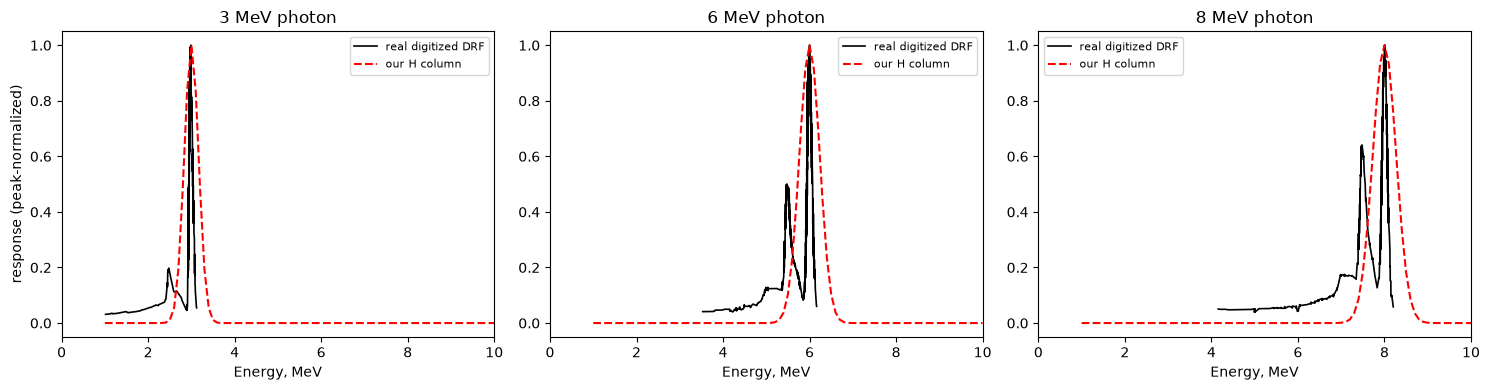

In [5]:
# Diagnostic: our H's REAL columns (red) vs the real digitized DRFs (black).

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

for j, (Eref, name) in enumerate([(3, "drf_3MeV"), (6, "drf_6MeV"), (8, "drf_8MeV")]):
    df = curves[name]

    # Real DRF: plotted at its OWN energies (df.x), unresampled, to keep the raw shape.
    ax[j].plot(df.x, df.y / df.y.max(), "k-", lw=1.2, label="real digitized DRF")

    # Our column, taken from H: pick the grid energy nearest Eref, pull that column.
    col_idx = np.argmin(np.abs(E - Eref))
    g = H[:, col_idx]
    ax[j].plot(E, g / g.max(), "r--", lw=1.5, label="our H column")

    ax[j].set_title(f"{Eref} MeV photon"); ax[j].set_xlim(0, 10)
    ax[j].set_xlabel("Energy, MeV"); ax[j].legend(fontsize=8)

ax[0].set_ylabel("response (peak-normalized)")
plt.tight_layout(); plt.show()

## Step 3 — forward check: does `H @ x_true` resemble Fig 1b (detector response -- forward)?

Compare *shapes* (area-normalized; Fig 1b/1c carry different absolute normalizations). Expect the
two peaks and falloff to line up, but our curve is too clean around the peaks (no shelf -- crompton).

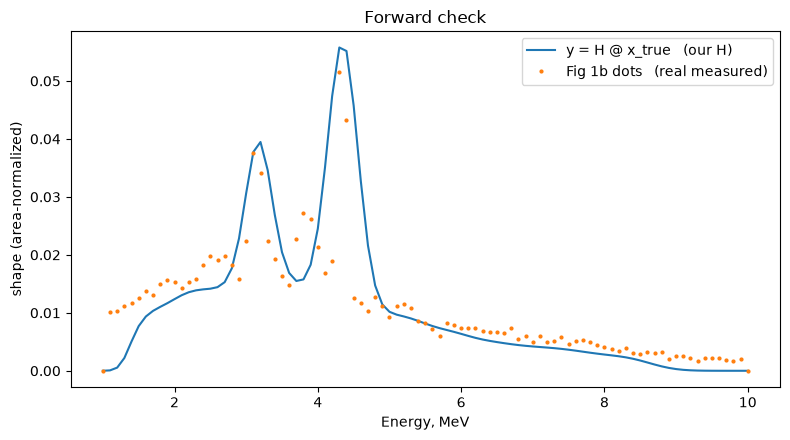

In [6]:
y_model = H @ x_true
m = curves["fig1b_meas"]
y_meas = np.interp(E, m.x.values, m.y.values, left=0.0, right=0.0)

norm = lambda v: v / v.sum() if v.sum() else v      # if the sum is zero, return the vector unchanged (to avoid division by zero)
plt.figure(figsize=(8, 4.5))
plt.plot(E, norm(y_model), "-", label="y = H @ x_true   (our H)")
plt.plot(E, norm(y_meas), ".", ms=4, label="Fig 1b dots   (real measured)")
plt.xlabel("Energy, MeV"); plt.ylabel("shape (area-normalized)")
plt.title("Forward check"); plt.legend(); plt.tight_layout(); plt.show()

## Step 4 — MLEM engine (Richardson–Lucy)

Multiplicative update from maximizing the Poisson likelihood of `y` given mean `H @ x`;
the multiplicative form keeps `x` non-negative automatically.

Paper-to-code map: `y_bar = H@x` is `Σ_k h_{j,k} x_k`; `Ht @ (y/y_bar)` is `Σ_j h_{j,i}(y_j/…)`;
`x/col` is the `x_i` prefactor (`col=Σ_j h_{j,i}=1` here, so a no-op kept for safety);
`np.clip` is `max(x,0)`.

The paper applies THREE SEPARATE oscillation-suppression tricks — kept distinct here:
  (1) in-loop smoothing every j iterations   -> `smooth_every`   (inside the loop)
  (2) a final 3-point linear average          -> `final_smooth`   (once, after the loop)
  (3) deconvolving with a ~30%-narrower DRF   -> pass a narrowed H (lives in H, not the loop)
All default OFF, so Run 2 shows the raw oscillations.

In [7]:
def three_point_average(v):
    """One pass of 3-point linear smoothing: each bin -> mean(itself, both neighbours).
    Edges are zero-padded by np.convolve(mode='same'), nudging the two end bins toward
    zero -- negligible here since the spectrum tails are ~0."""
    return np.convolve(v, np.ones(3) / 3.0, mode="same")


def mlem(y, H, n_iter=200, smooth_every=0, final_smooth=False):
    """MLEM / Richardson-Lucy deconvolution: recover x from y given response H.

    Two of the paper's three oscillation-suppression tricks live here; the third
    (narrowed DRF) lives in H and is applied by passing a narrower H as the argument.

      smooth_every = j  -> (1) IN-LOOP smoothing: smooth every j-th iteration, DURING
                           iteration, to damp oscillations as they grow.
                           Paper: "smoothing after every j iterations ... reduces oscillation."
                           (Paper does not specify the in-loop kernel; 3-point is our choice.)
      final_smooth=True -> (2) FINAL smoothing: ONE 3-point pass AFTER the loop, on the
                           finished result. Paper: "After deconvolution, linear smoothing
                           with respect to three points was performed."

    Independent switches -- enable any subset. Defaults: both OFF.
    """
    Ht = H.T
    col = H.sum(axis=0); col[col == 0] = 1e-12
    x = np.full(H.shape[1], y.sum() / H.shape[1])       # flat, strictly-positive start

    for it in range(1, n_iter + 1):
        y_bar = H @ x; y_bar[y_bar == 0] = 1e-12         # predicted measurement Σ_k h_{j,k} x_k
        correction = Ht @ (y / y_bar)                    # back-project Σ_j h_{j,i}(y_j / pred_j)
        x = x / col * correction                         # multiplicative update (keeps x >= 0)
        x = np.clip(x, 0.0, None)                         # paper's explicit max(x, 0)

        # (1) IN-LOOP smoothing -- periodic, during iteration.
        if smooth_every and it % smooth_every == 0:
            x = three_point_average(x)

    # (2) FINAL smoothing -- one pass, after the loop completes.
    if final_smooth:
        x = three_point_average(x)

    return x

### Run 1 — self-consistency (must return `x_true`)

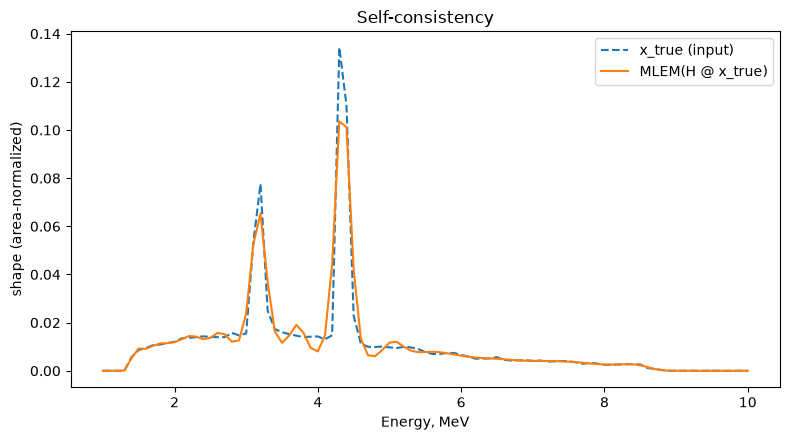

recovered peak 4.30 MeV   (x_true peak 4.30 MeV)


In [8]:
x_self = mlem(y_model, H, n_iter=200)
plt.figure(figsize=(8, 4.5))
plt.plot(E, norm(x_true), "--", label="x_true (input)")
plt.plot(E, norm(x_self), "-",  label="MLEM(H @ x_true)")
plt.xlabel("Energy, MeV"); plt.ylabel("shape (area-normalized)")
plt.title("Self-consistency"); plt.legend(); plt.tight_layout(); plt.show()
print("recovered peak", f"{E[x_self.argmax()]:.2f} MeV   (x_true peak {E[x_true.argmax()]:.2f} MeV)")

### Run 2 — real benchmark (invert digitized Fig 1b; compare to paper Fig 1c)
Expect oscillations: our Gaussian H ≠ the real detector. Try `smooth_every=20` to see the paper's fix.

In [9]:
# (3) narrowed-DRF trick: invert with a ~30% narrower response than the true H.
# Gentler deconvolution -> fewer oscillations (costs some resolution).
H_decon = build_H(E, 0.7 * k)                       # narrower H, made via the same recipe
x_bench = mlem(y_meas, H_decon, n_iter=200)
r = curves["fig1c_recon"]
x_paper = np.interp(E, r.x.values, r.y.values, left=0.0, right=0.0)
plt.figure(figsize=(8, 4.5))
plt.plot(E, norm(x_paper), "--", label="Fig 1c solid (paper recon)")
plt.plot(E, norm(x_bench), "-",  label="MLEM(real Fig 1b, our H)")
plt.xlabel("Energy, MeV"); plt.ylabel("shape (area-normalized)")
plt.title("Real benchmark vs paper"); plt.legend(); plt.tight_layout(); plt.show()

TypeError: build_H() missing 1 required positional argument: 'k'

## Where this leaves us

**Passed:** runs end-to-end on real data; self-consistency clean (engine + H wired right); forward
model reproduces the Fig 1b two-peak structure.

**First-pass limits (flagged in-code):** Gaussian only, no Compton shelf; `FWHM` calibrated to one
width; columns away from 3/6/8 MeV are modelled, not measured.

**For the prof:** (1) full interpolated H or 3-column PoC? (2) careful H via peak+shelf fit, or MCNP
DRF for ADITYA-U? (3) is this benchmark the agreed milestone before real ADITYA-U data?

**Next (careful H):** replace Gaussian columns with peak+shelf shapes fit to the three real DRFs,
then re-run Run 2 — oscillations should drop and the Fig 1c match should tighten.